# MLP Ablations

Open-ended ablation program testing whether anything beats the standing baseline MLP, batch size recheck, feature swaps, architecture capacity/depth, feature design, and the split-choice noise floor every comparison here is judged against. Foundational, settled decisions (class taxonomy, bin count, baseline train/eval) live in `mlp_classifier.ipynb`; this notebook is for open questions, not settled ones, and keeps growing as new ideas get tested.


## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from build_points_table import build_and_save_points_table
from taxonomy_separability import add_relative_features
from mlp_classifier import apply_mlp_class_groups
from mlp_variants import run_variant
from split_sensitivity import run_split_sensitivity


In [2]:
df = build_and_save_points_table()
df = add_relative_features(df)
df = apply_mlp_class_groups(df)


/home/bruno/radar_machine_learning_ws/results/data/points_table.parquet already covers exactly the requested sequences, skipping build


Baseline reference (cached, no retraining), every comparison below is measured against this.

/home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.937   0.784  0.854    31055
large_vehicle         0.719   0.797  0.756     6247
two_wheeler           0.475   0.545  0.508     4629
pedestrian            0.534   0.944  0.682    11325
pedestrian_group      0.754   0.544  0.632    17858


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_confusion_matrix.png
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_precision_recall_f1.png


,precision,recall,f1,support
car,0.937115,0.784093,0.853802,31055
large_vehicle,0.719491,0.796542,0.756059,6247
two_wheeler,0.475302,0.544610,0.507601,4629
pedestrian,0.533806,0.943929,0.681956,11325
pedestrian_group,0.754346,0.544238,0.632295,17858


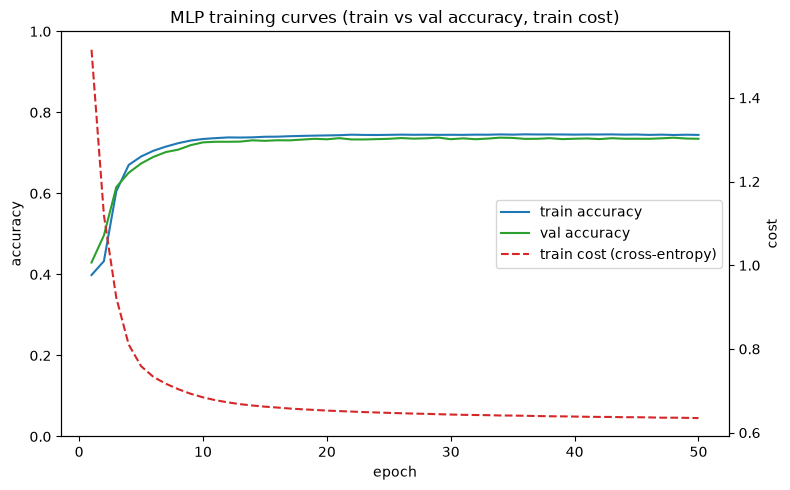

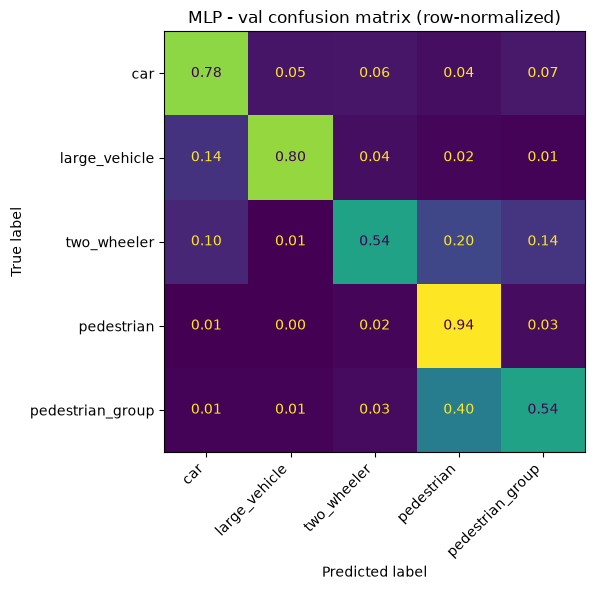

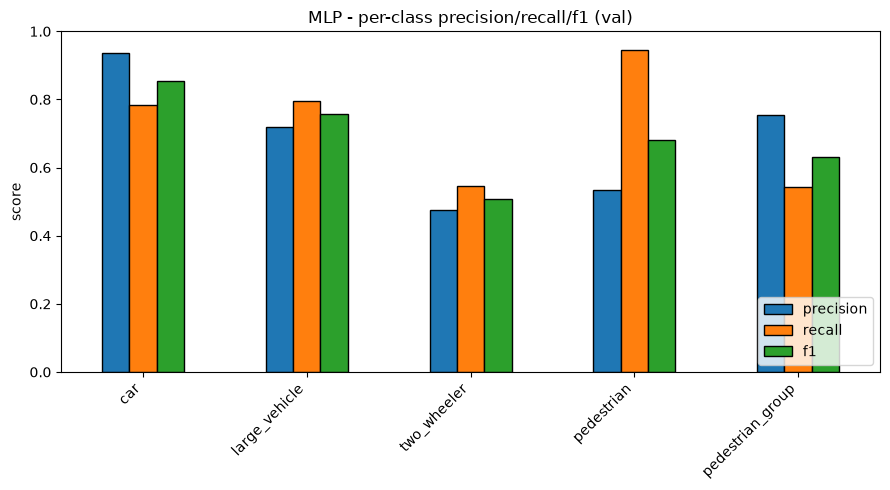

In [3]:
_, _, baseline_metrics, _, _ = run_variant(df, "baseline")
baseline_metrics


## Feature swap: range_sc

Same architecture/training config as `baseline`, but `range_sc` (per point sensor range) binned into the same N_BINS=16 columns used for `rcs`/`vr_compensated`/`x_rel`/`y_rel`, instead of `doppler_spread` appended unbinned. `bs32` separately rechecks `BATCH_SIZE`/`LEARNING_RATE` now that bus, the original binding constraint, is merged into `large_vehicle`. Both defined in `scripts/mlp_variants.py`.

/home/bruno/radar_machine_learning_ws/results/mlp/range_sc/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/range_sc/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/range_sc/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.939   0.771  0.847    31055
large_vehicle         0.655   0.797  0.719     6247
two_wheeler           0.501   0.641  0.563     4629
pedestrian            0.590   0.861  0.700    11325
pedestrian_group      0.743   0.648  0.692    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/range_sc/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/range_sc/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/bs32/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/bs32/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/bs32/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.937   0.782  0.852    31055
large_vehicle         0.717   0.791  0.753     6247
two_wheeler           0.488   0.541  0.513     4629
pedestrian            0.540   0.934  0.684    11325
pedestrian_group      0.731   0.555  0.631    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/bs32/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/bs32/mlp_precision_recall_f1.png


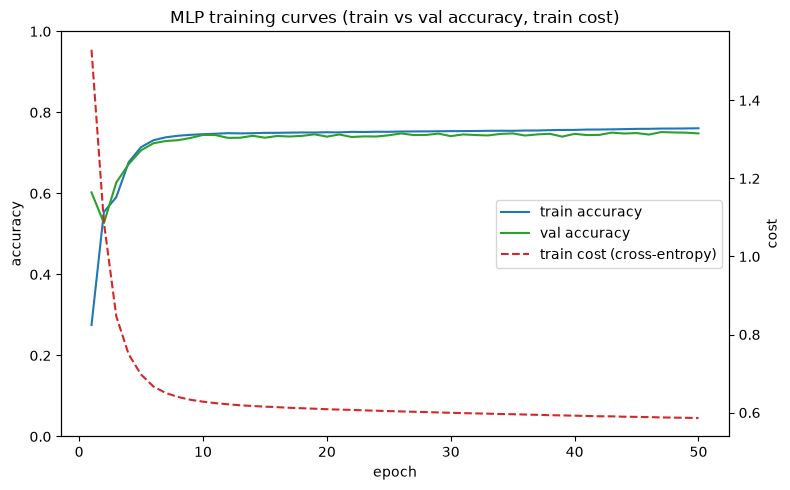

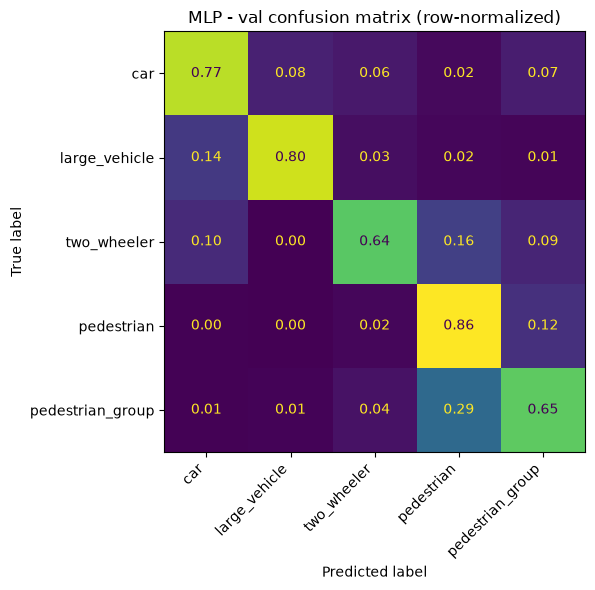

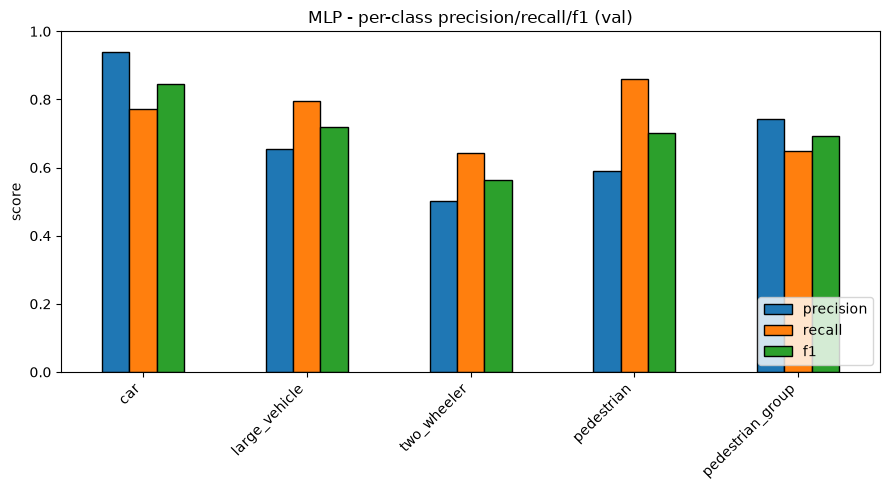

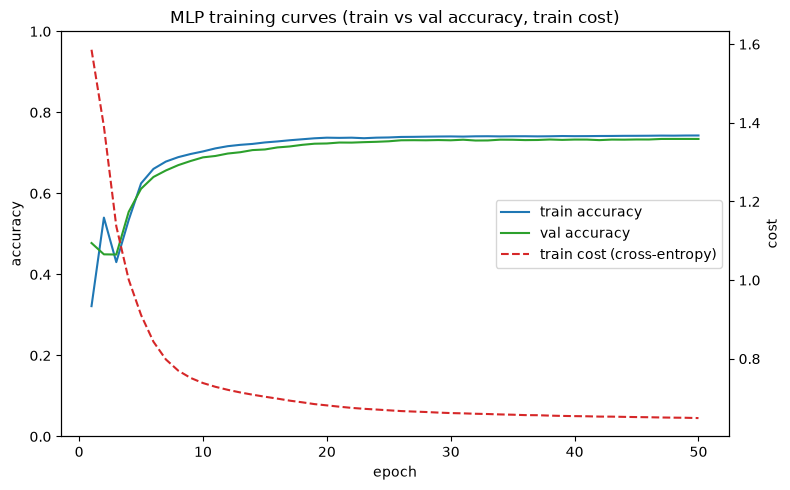

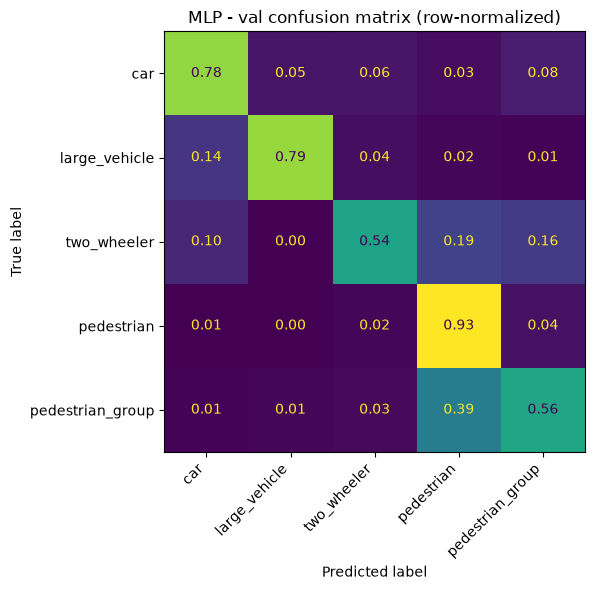

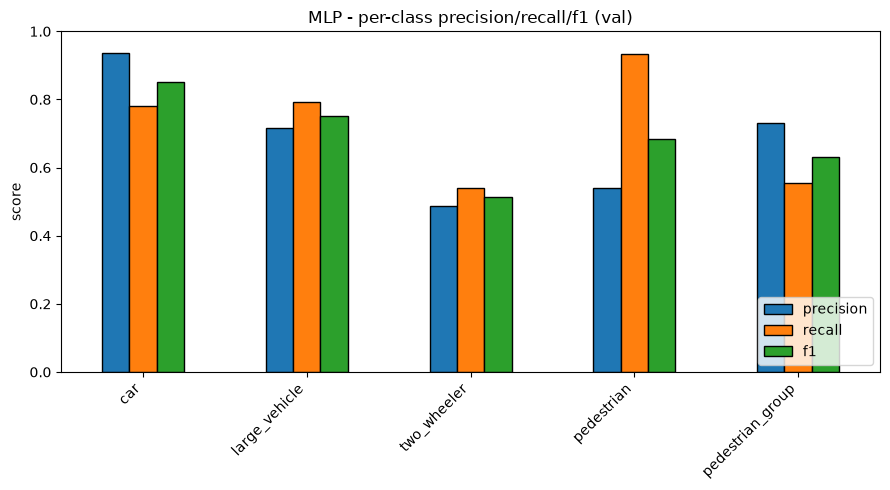

In [4]:
# both cached, no retraining
_, _, range_sc_metrics, _, _ = run_variant(df, "range_sc")
_, _, bs32_metrics, _, _ = run_variant(df, "bs32")

In [5]:
range_sc_metrics

,precision,recall,f1,support
car,0.939141,0.770697,0.846622,31055
large_vehicle,0.654914,0.796862,0.718949,6247
two_wheeler,0.501182,0.641391,0.562684,4629
pedestrian,0.590084,0.860662,0.700140,11325
pedestrian_group,0.742590,0.648113,0.692142,17858


In [6]:
bs32_metrics

,precision,recall,f1,support
car,0.936661,0.781903,0.852314,31055
large_vehicle,0.717458,0.791420,0.752626,6247
two_wheeler,0.488204,0.540938,0.513220,4629
pedestrian,0.539525,0.934128,0.683994,11325
pedestrian_group,0.731161,0.555269,0.631190,17858


Macro F1: `baseline` 0.686, `range_sc` 0.704, `bs32` 0.687. `range_sc` initially looked better, but see the split sensitivity check below: that gap is within normal split-to-split noise, not a real improvement. `bs32` is essentially identical to `baseline`, `BATCH_SIZE=128` stays.

Full writeup: `MLP_Decisions_and_Findings.md` section 5.

## Split sensitivity check

Is a macro F1 difference like `range_sc`'s (0.018 vs `baseline`) real, or just noise from which sequences happen to land in val? Tried picking a "better" val set by generating the 6 distinct valid splits at the fixed 70/15/15 proportions and scoring each by how closely train and val's per-class feature distributions matched (two-sample Kolmogorov-Smirnov statistic), then trained `baseline`'s exact config on all 6.

`scripts/split_sensitivity.py`, results at `results/mlp/split_search/fold_<n>/`.

 random_state  fold  n_val_sequences  mean_ks  max_ks
            0     0               22   0.0557  0.1793
            1     0               22   0.0557  0.1793
            2     0               22   0.0557  0.1793
            3     0               22   0.0557  0.1793
            4     0               22   0.0557  0.1793
            5     0               22   0.0557  0.1793
            6     0               22   0.0557  0.1793
            7     0               22   0.0557  0.1793
            8     0               22   0.0557  0.1793
            9     0               22   0.0557  0.1793
            0     2               19   0.0588  0.2857
            1     2               19   0.0588  0.2857
            2     2               19   0.0588  0.2857
            3     2               19   0.0588  0.2857
            4     2               19   0.0588  0.2857
            5     2               19   0.0588  0.2857
            6     2               19   0.0588  0.2857
            7     2         

/home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_0/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_0/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_0/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.930   0.807  0.864    31363
large_vehicle         0.726   0.709  0.717     6243
two_wheeler           0.474   0.753  0.582     4720
pedestrian            0.502   0.915  0.648    11074
pedestrian_group      0.781   0.465  0.583    18757
Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_0/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_0/mlp_precision_recall_f1.png
fold 0 macro F1: 0.6788
=== fold 1 (max_ks=0.6238) ===


/home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_1/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_1/mlp_training_curves.png


...

Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_4/mlp_precision_recall_f1.png
fold 4 macro F1: 0.6953
=== fold 5 (max_ks=0.2870) ===


/home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_5/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_5/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_5/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.949   0.812  0.875    29555
large_vehicle         0.764   0.866  0.812     6312
two_wheeler           0.405   0.669  0.505     4831
pedestrian            0.538   0.919  0.679    11605
pedestrian_group      0.805   0.443  0.572    17668
Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_5/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_5/mlp_precision_recall_f1.png
fold 5 macro F1: 0.6884

macro F1 range: 0.651 - 0.734, std: 0.027
 fold   max_ks  macro_f1
    0 0.179348  0.678828
    1 0.623832  0.734235
    2 0.285685  0.700931
    3 0.336050  0.651298
    4 0.286753  0.695262
    5 0.287041  0.688433


,fold,max_ks,macro_f1
0,0,0.179348,0.678828
1,1,0.623832,0.734235
2,2,0.285685,0.700931
3,3,0.336050,0.651298
4,4,0.286753,0.695262
5,5,0.287041,0.688433


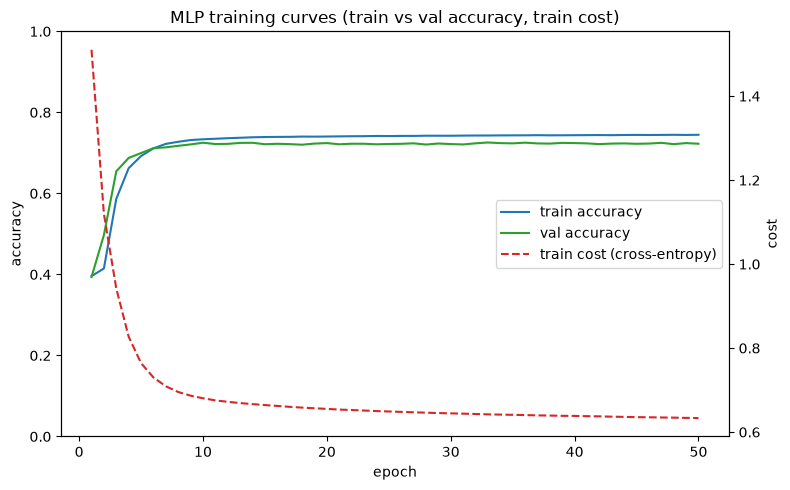

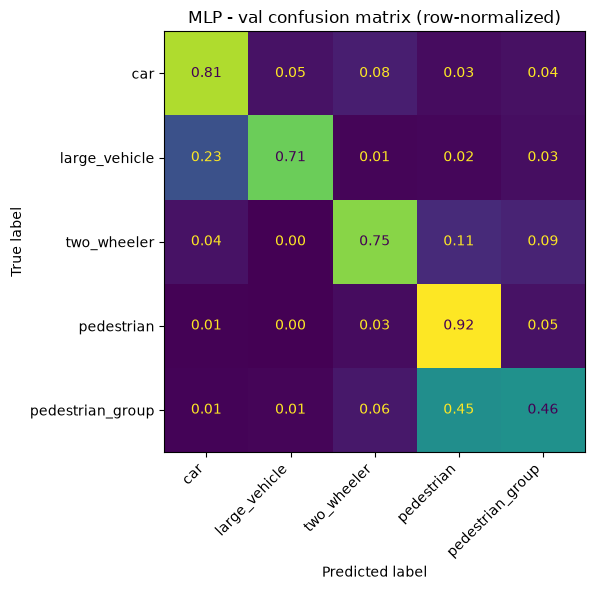

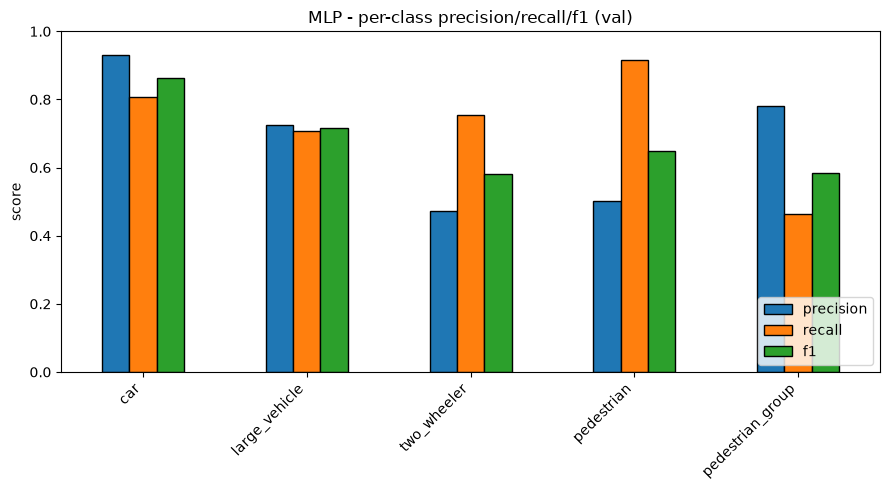

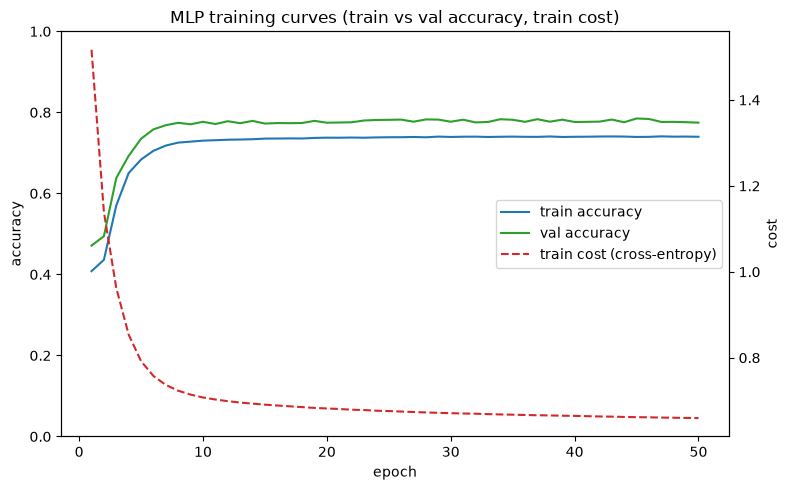

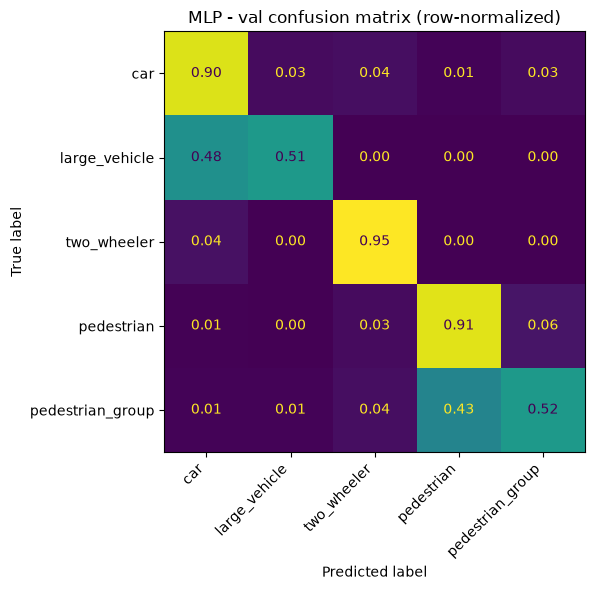

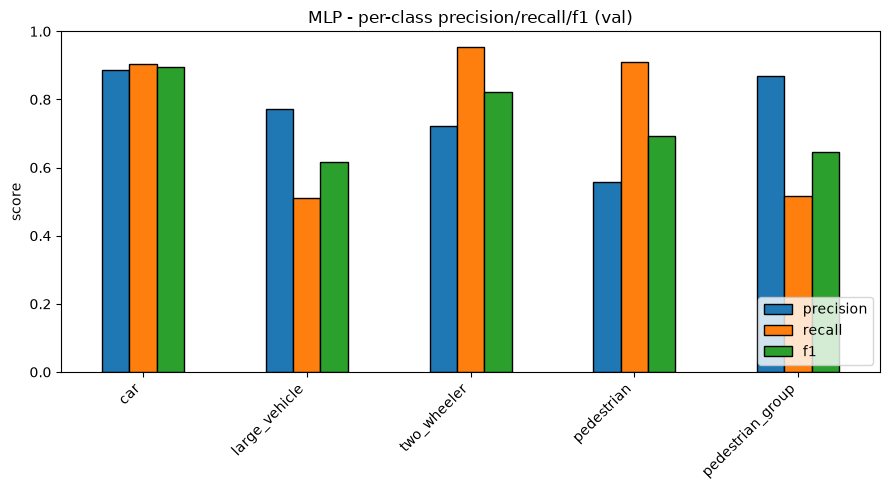

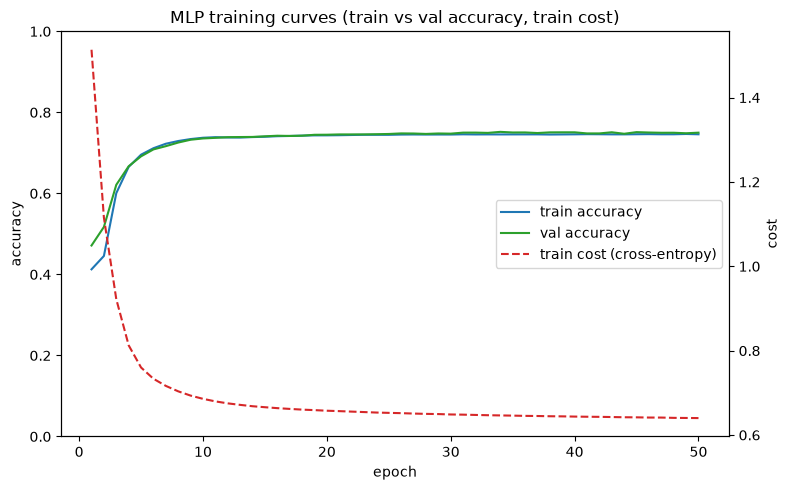

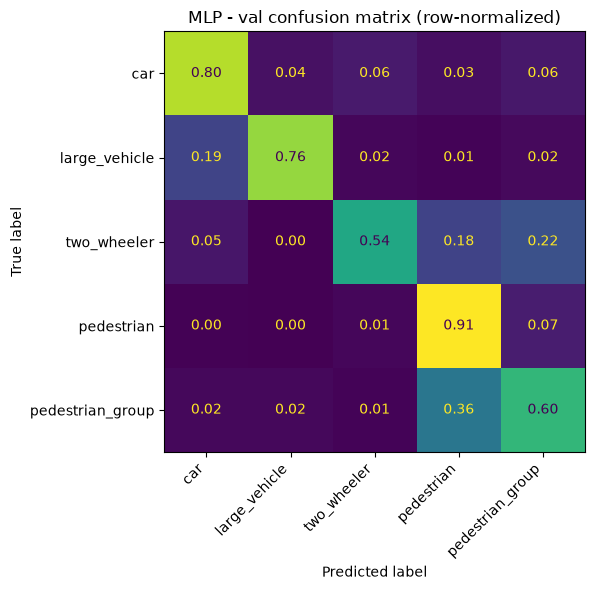

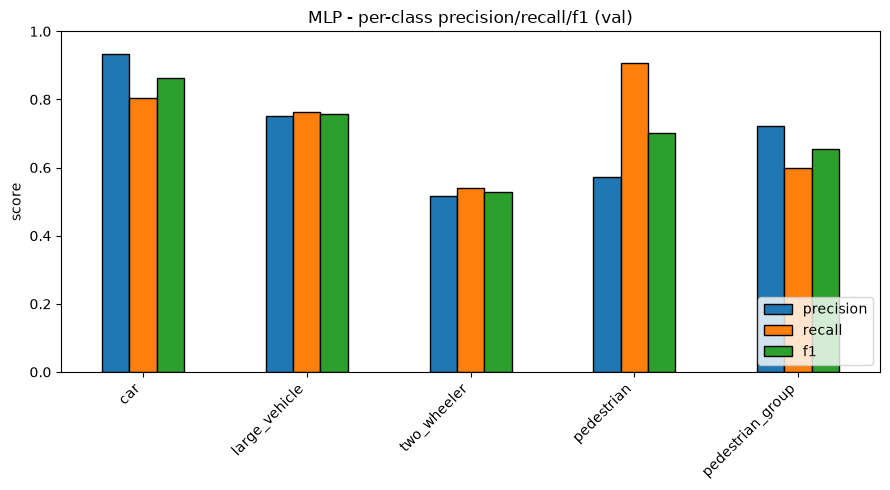

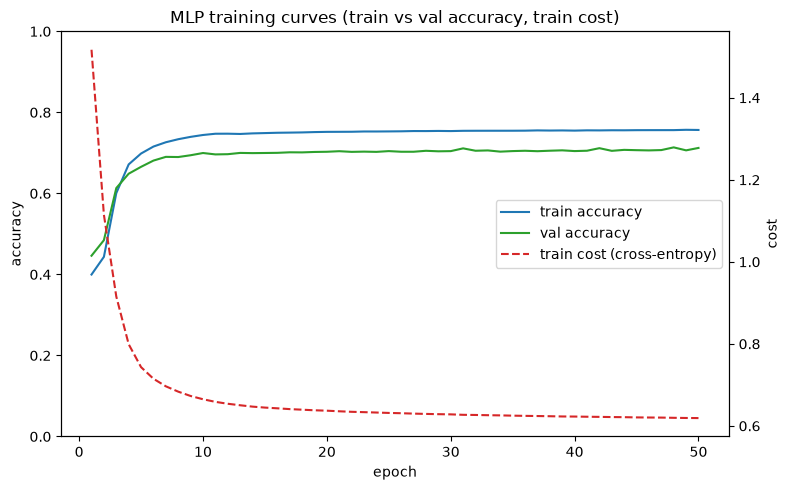

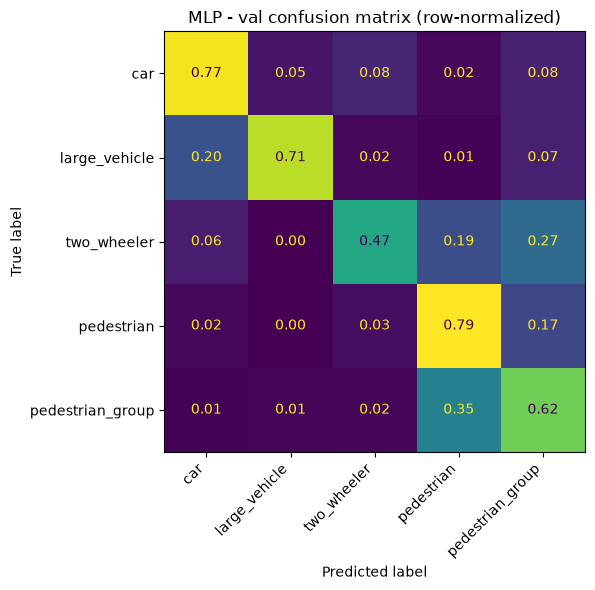

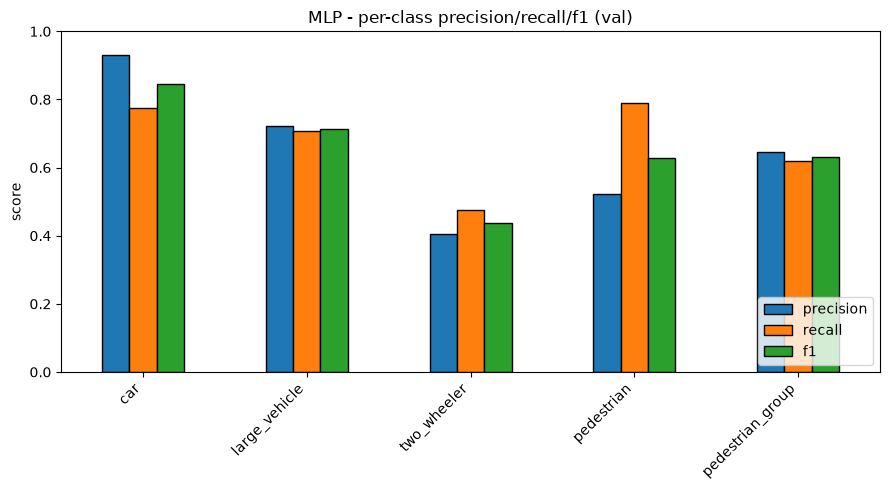

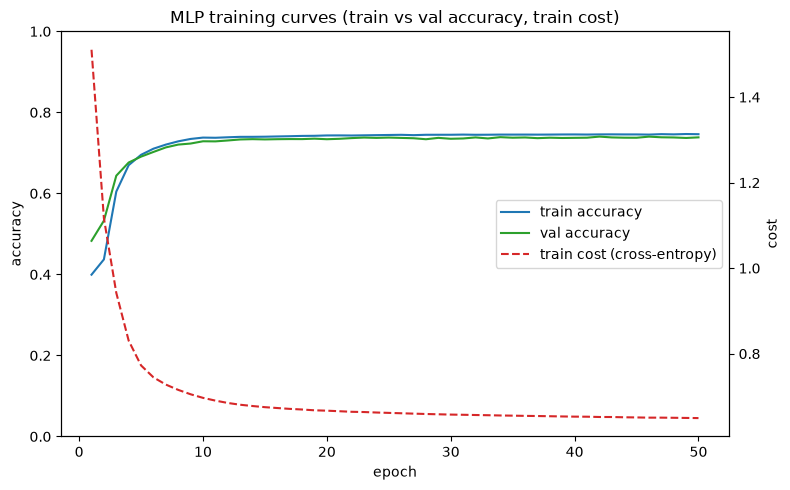

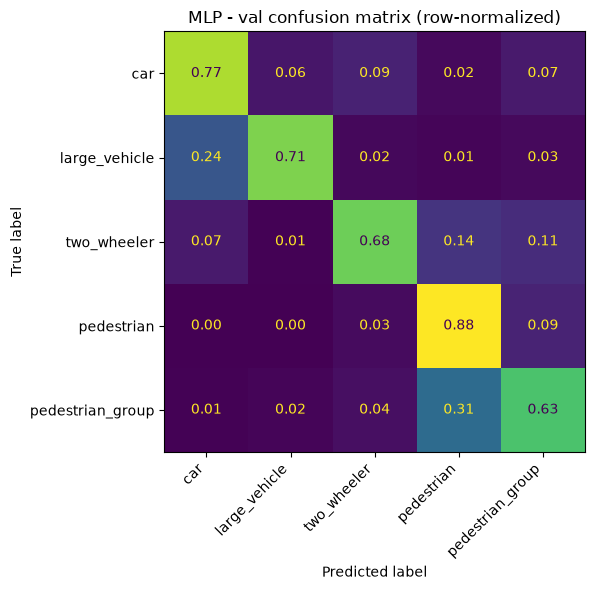

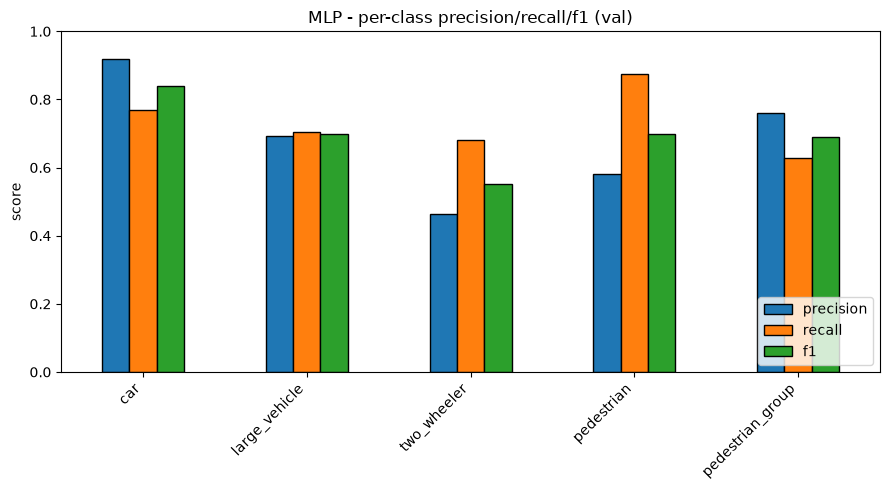

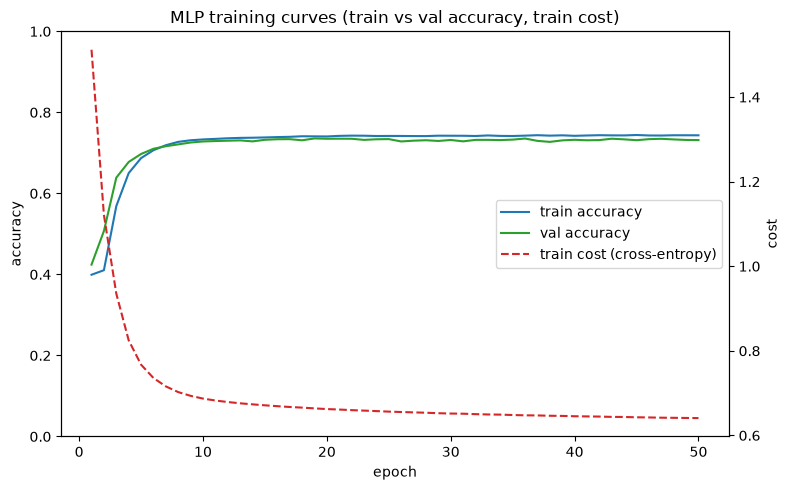

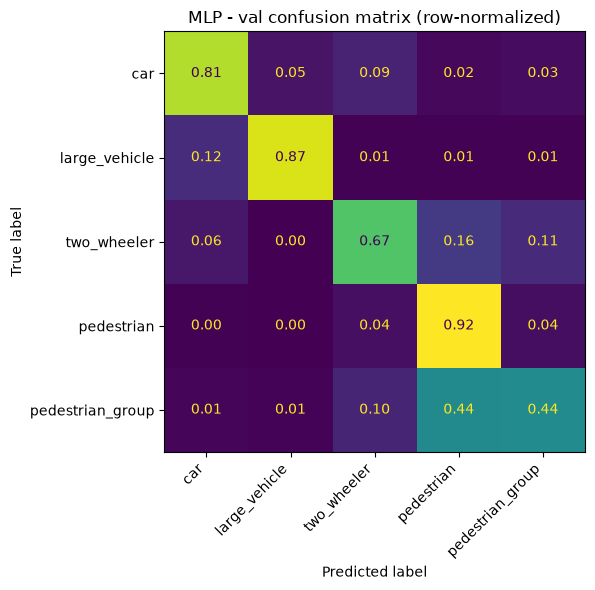

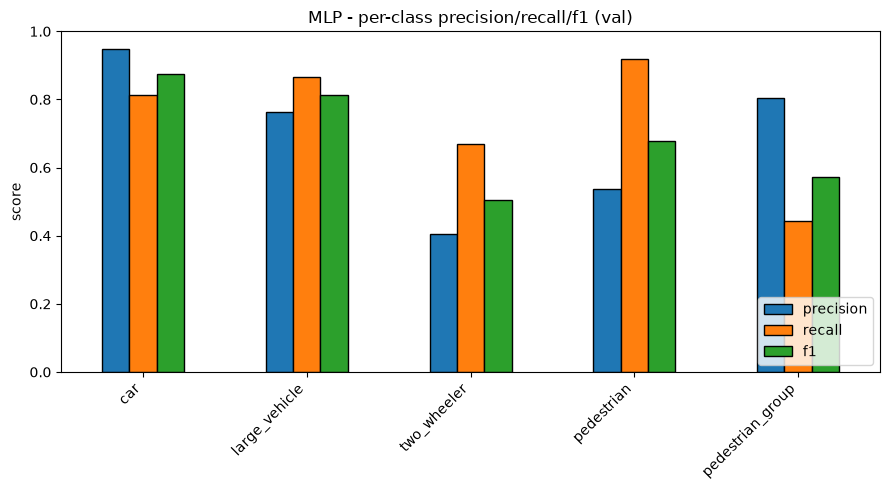

In [7]:
# cached - reruns the KS scoring (cheap) and loads each fold's cached model, no retraining
split_summary = run_split_sensitivity(df)
split_summary

Macro F1 ranged 0.651 to 0.734 across the 6 splits, purely from which sequences landed in val, wider than the `range_sc` gap (0.018). The split with the best-matching train/val distributions actually scored near the worst, and the worst-matching one scored best, so distribution match didn't predict model performance either.

**Decision:** keep the standing split, no candidate is a demonstrated improvement. The `range_sc` vs `baseline` comparison is closed as noise, not a real gain.

Root cause, briefly: a sequence-grouped split can't guarantee a class's radar signature (aspect angle, motion state) is well mixed between train and val when that class is concentrated in a handful of sequences, e.g. a bicycle stopped at a light (near-zero Doppler, narrow RCS) versus one crossing broadside (also near-zero Doppler, but much larger RCS) are the same label with very different feature distributions. Full writeup, including the sequence-concentration mechanism and general lesson for future projects: `MLP_Decisions_and_Findings.md`, Key takeaways.

## Architecture capacity: hidden_dim ablation

Is the 16-unit hidden layer actually a bottleneck, or does the histogram feature representation cap performance regardless of model size? Same architecture shape (2 hidden layers), same features/taxonomy/batch size/LR/epochs as `baseline`, only `hidden_dim` changes: 8, 32, 64, against the standing 16. Defined in `scripts/mlp_variants.py`.

/home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.942   0.786  0.857    31055
large_vehicle         0.705   0.797  0.748     6247
two_wheeler           0.485   0.537  0.509     4629
pedestrian            0.553   0.877  0.679    11325
pedestrian_group      0.709   0.597  0.648    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_curves.png


...

Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden32/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.939   0.786  0.856    31055
large_vehicle         0.681   0.805  0.738     6247
two_wheeler           0.469   0.561  0.511     4629
pedestrian            0.558   0.853  0.674    11325
pedestrian_group      0.725   0.603  0.659    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_precision_recall_f1.png


,variant,hidden_dim,macro_f1
0,hidden8,8,0.688272
1,baseline,16,0.686342
2,hidden32,32,0.687698
3,hidden64,64,0.687536


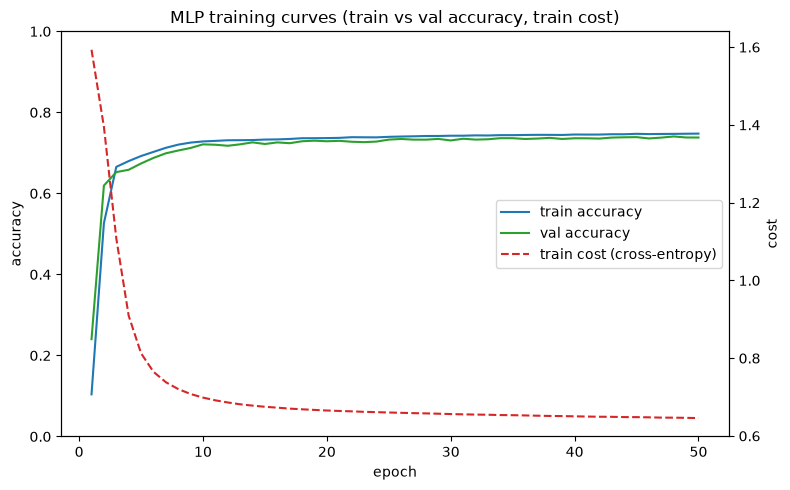

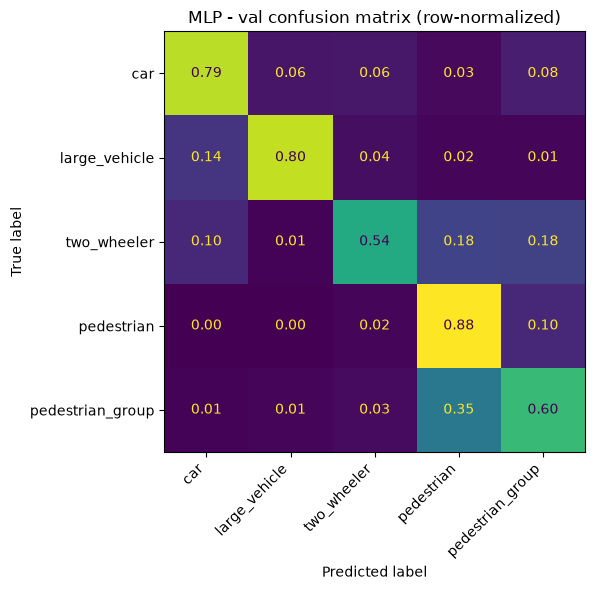

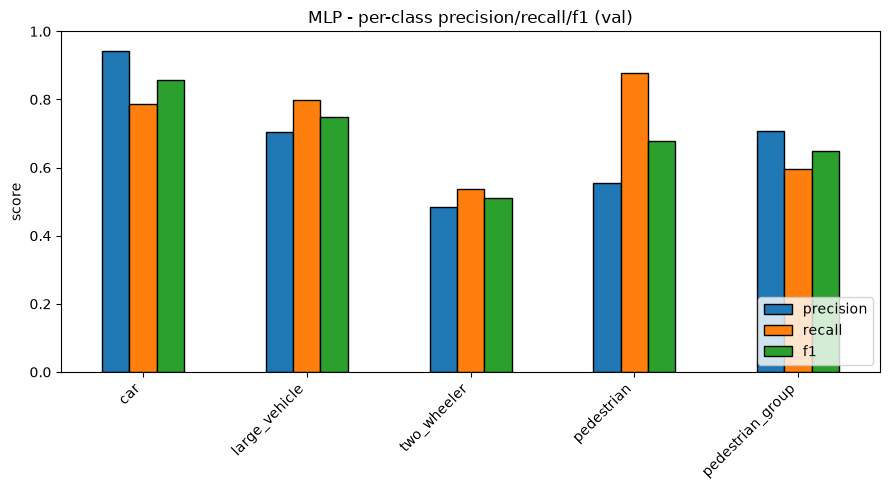

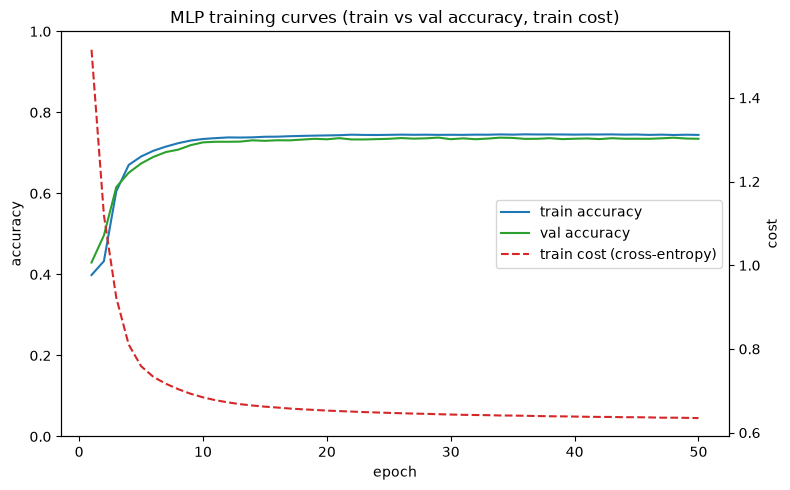

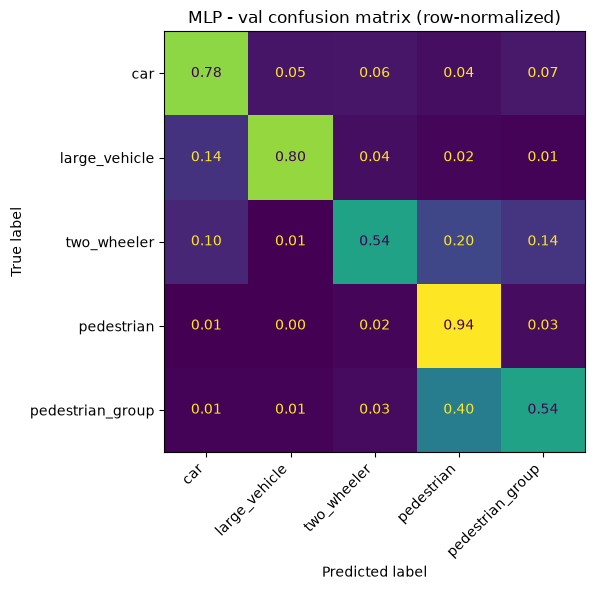

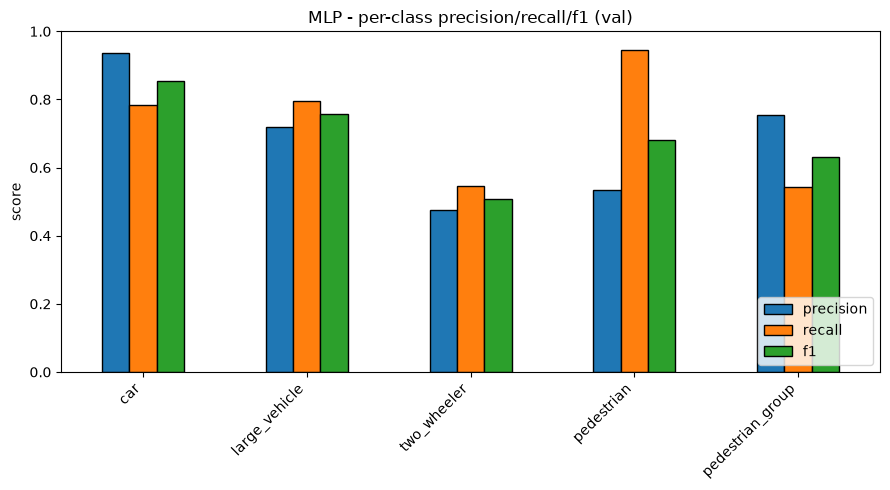

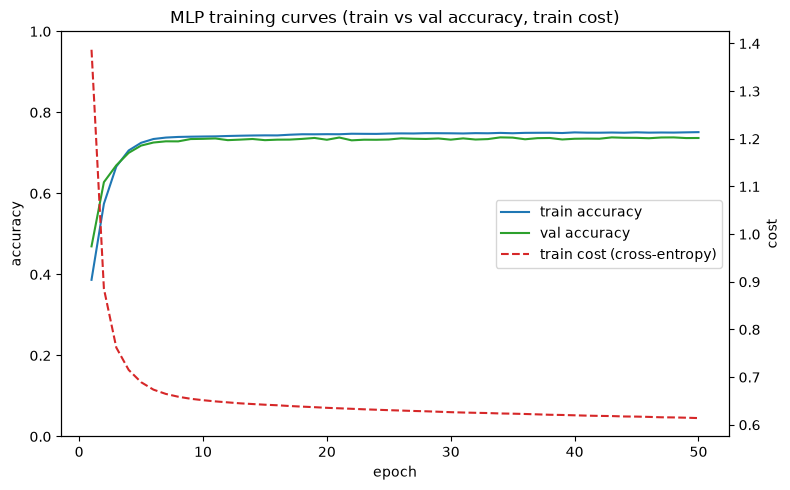

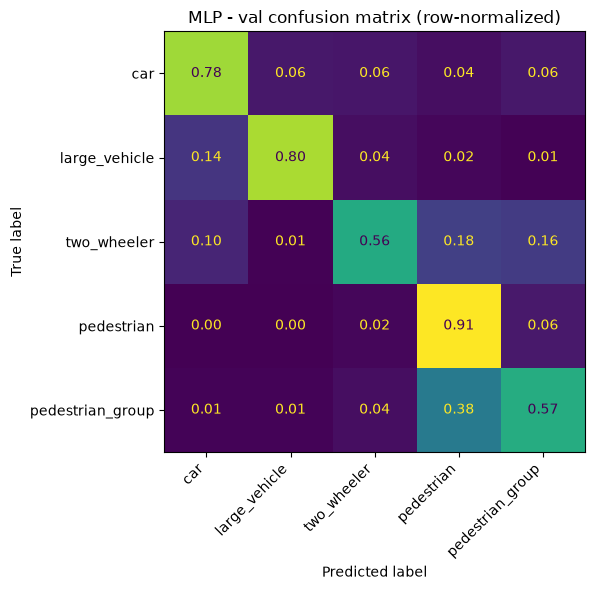

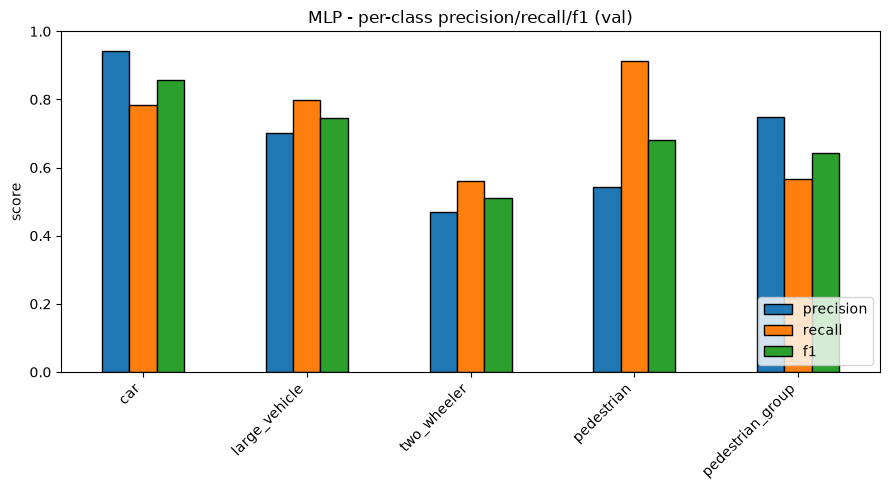

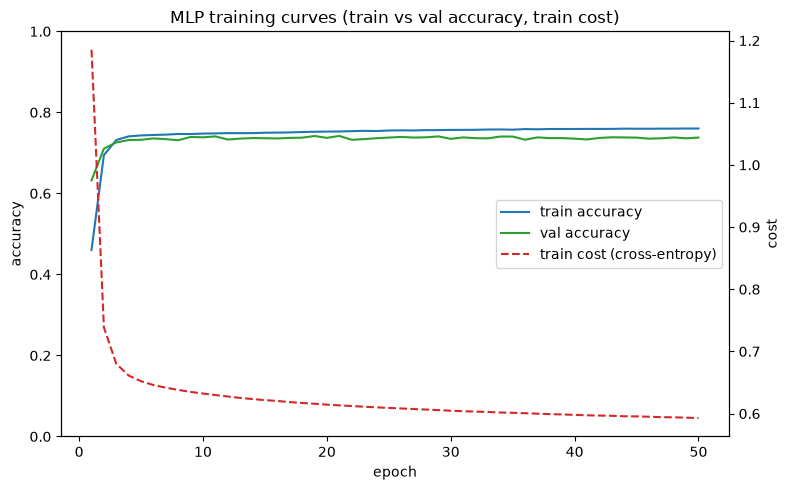

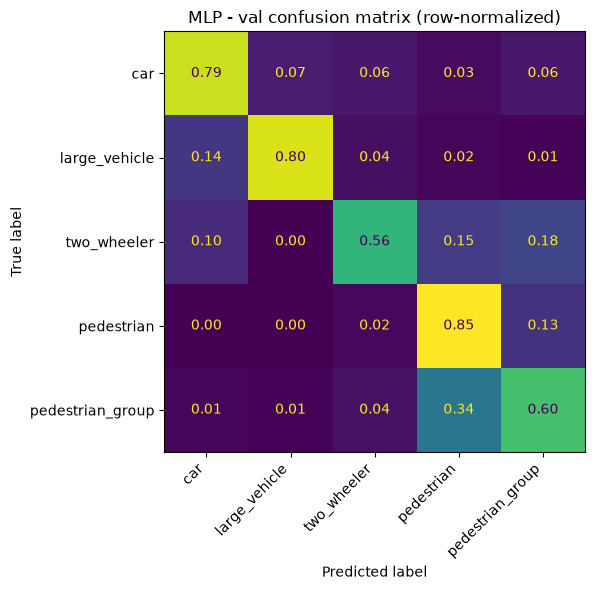

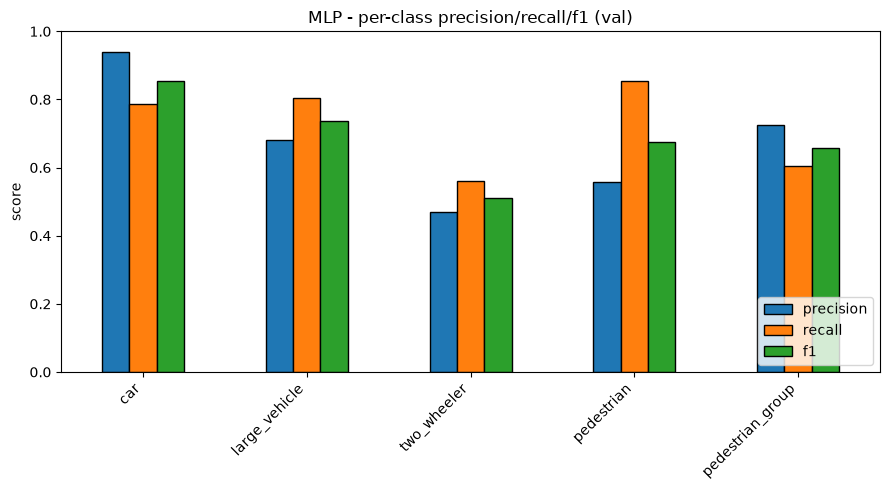

In [8]:
# all cached, no retraining
hidden_dims = {"hidden8": 8, "baseline": 16, "hidden32": 32, "hidden64": 64}
hidden_rows = []
for variant, dim in hidden_dims.items():
    _, _, m, _, _ = run_variant(df, variant)
    hidden_rows.append({"variant": variant, "hidden_dim": dim, "macro_f1": m["f1"].mean()})

import pandas as pd
pd.DataFrame(hidden_rows)

Macro F1: 0.688 (`hidden8`), 0.686 (`baseline`, 16), 0.688 (`hidden32`), 0.688 (`hidden64`), all within 0.002 of each other, far inside the measured noise floor (std 0.027 from the split sensitivity check above). Going from 8 to 64 units, an 8x range, moves nothing.

**Finding:** the model isn't capacity-limited. The histogram feature representation is the ceiling, not the network's expressive power, consistent with the feature-separability-ceiling read of the `bus`/`large_vehicle` confusion earlier in this notebook.

**Decision:** retain `HIDDEN_DIM=16`, no reason to spend more compute on a larger model for no measurable gain.

Full writeup: `MLP_Decisions_and_Findings.md` section 6.

### Per-class check: is capacity hiding behind the macro average?

Macro F1 could be flat while individual classes trade off against each other. Checked directly, and cross-checked against the per-class spread already measured from split choice alone (the split sensitivity table above), since that's the real noise floor to judge against, not intuition.

/home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.942   0.786  0.857    31055
large_vehicle         0.705   0.797  0.748     6247
two_wheeler           0.485   0.537  0.509     4629
pedestrian            0.553   0.877  0.679    11325
pedestrian_group      0.709   0.597  0.648    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_history.json already matches this config, loading cached model + history


...

Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden32/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.939   0.786  0.856    31055
large_vehicle         0.681   0.805  0.738     6247
two_wheeler           0.469   0.561  0.511     4629
pedestrian            0.558   0.853  0.674    11325
pedestrian_group      0.725   0.603  0.659    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_precision_recall_f1.png


,hidden_dim spread (8-64),"split-choice spread (6 folds, noise reference)"
car,0.003156,0.055956
large_vehicle,0.018220,0.196742
two_wheeler,0.004527,0.385549
pedestrian,0.007586,0.073356
pedestrian_group,0.026466,0.116629


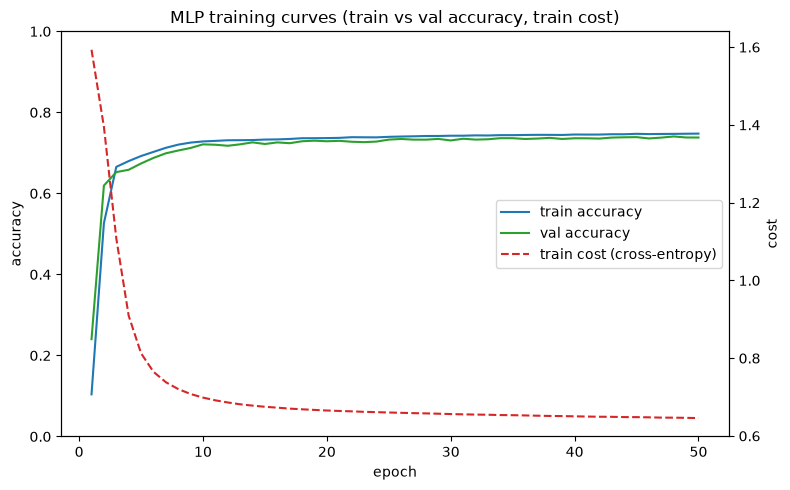

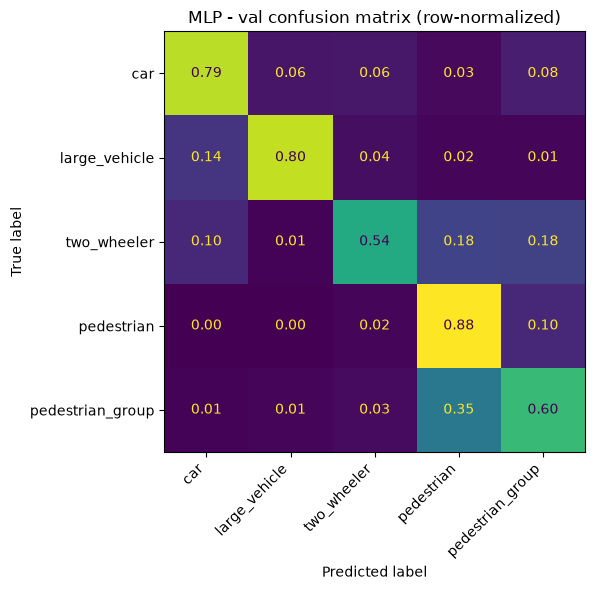

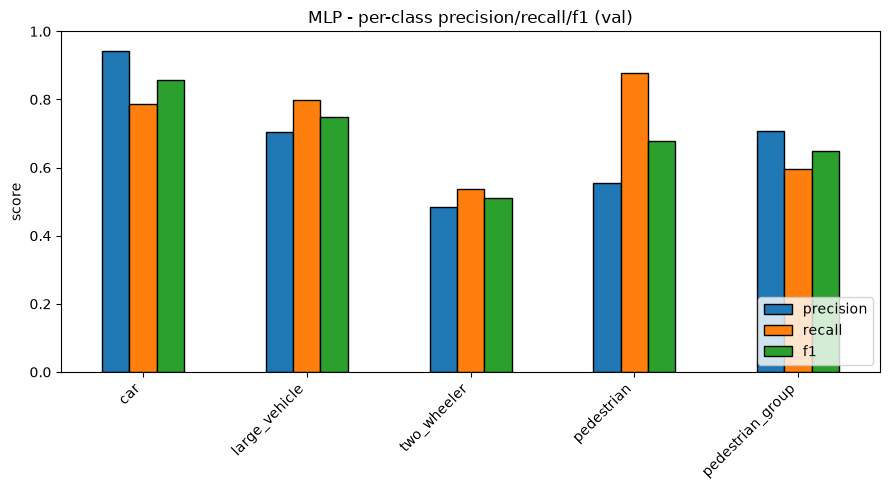

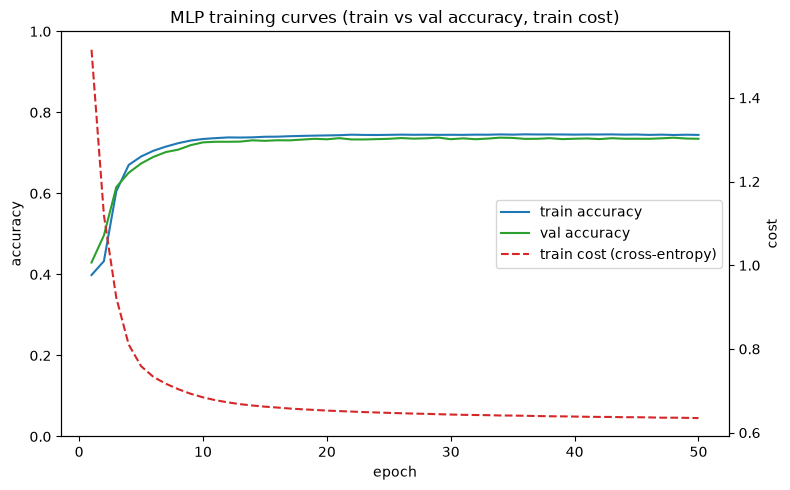

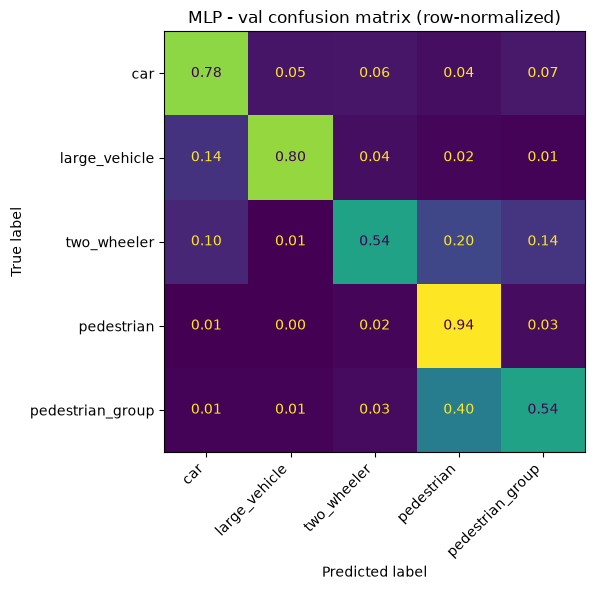

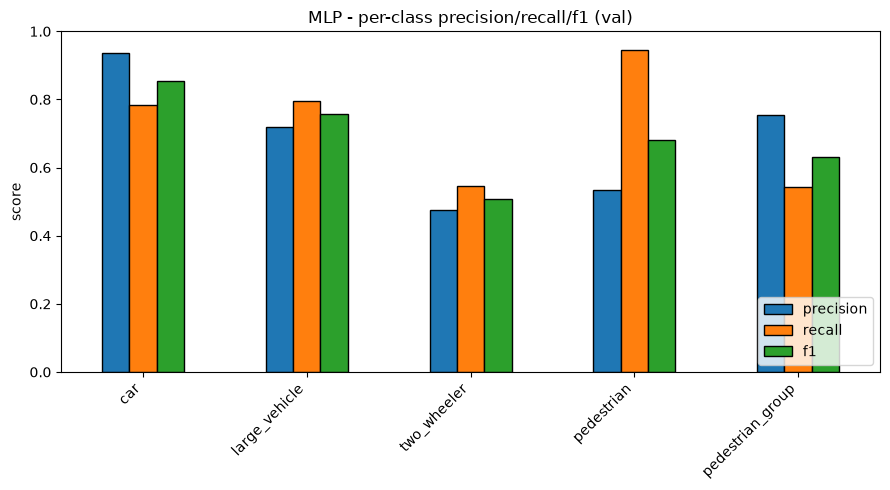

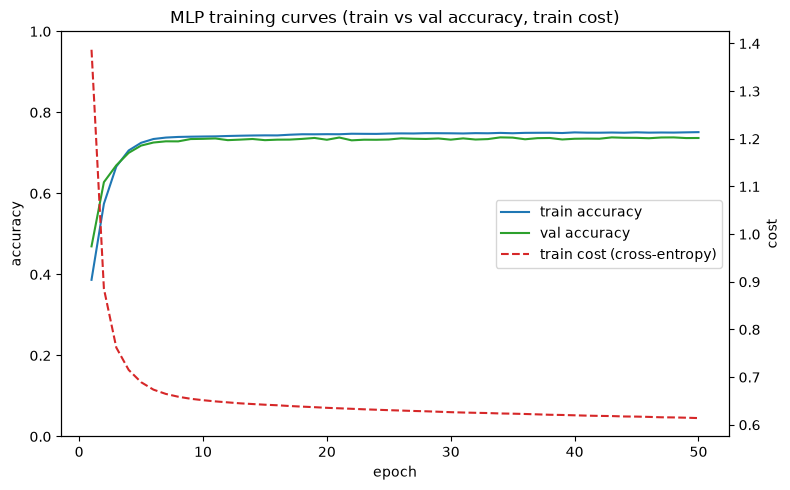

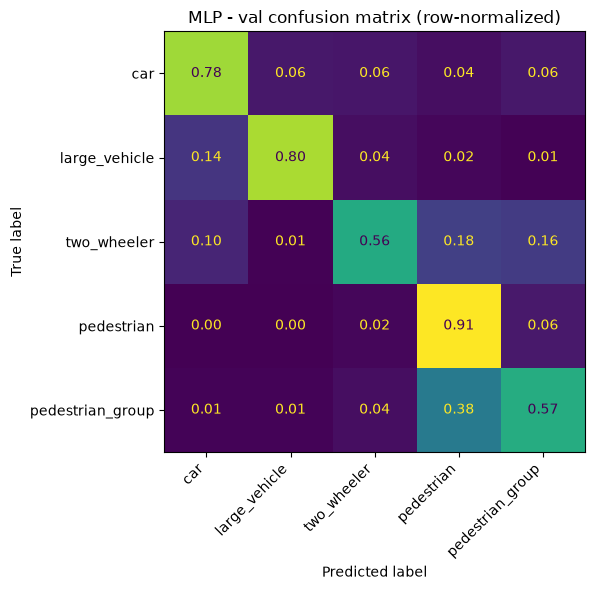

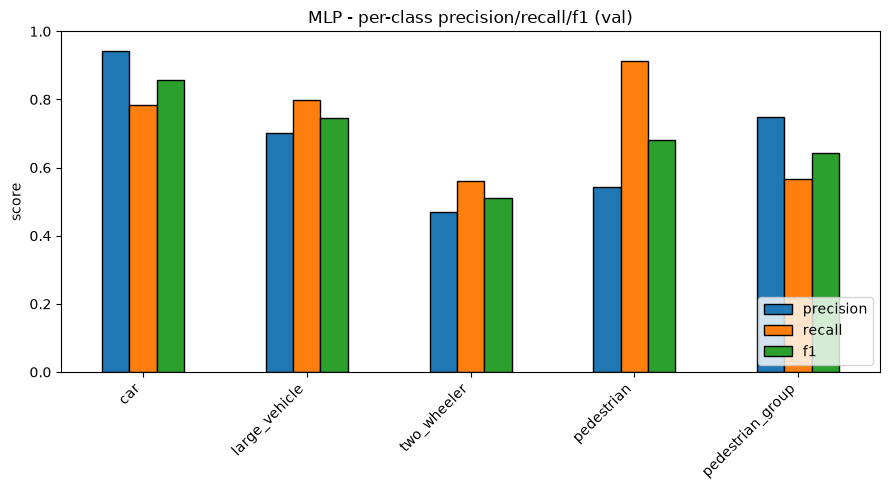

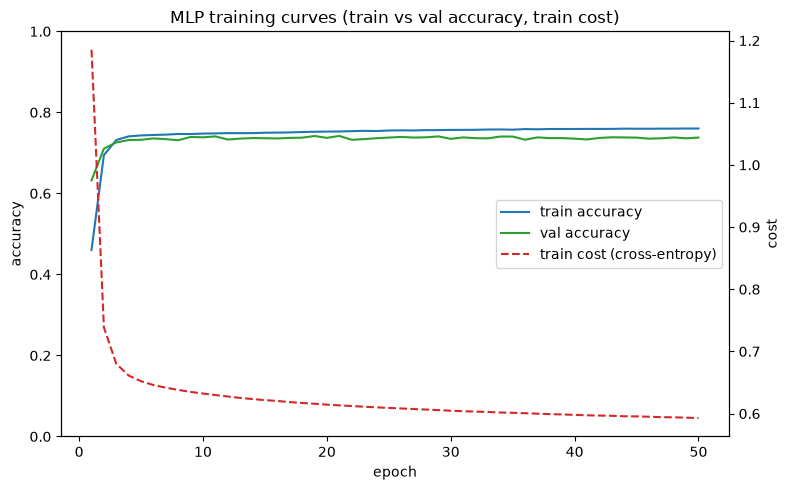

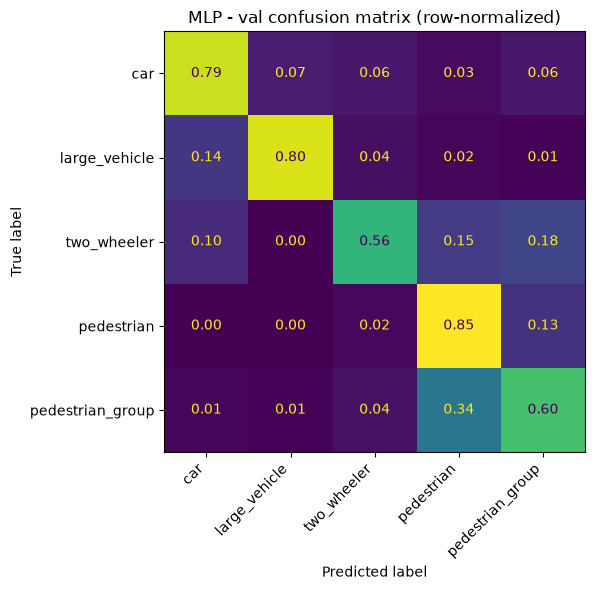

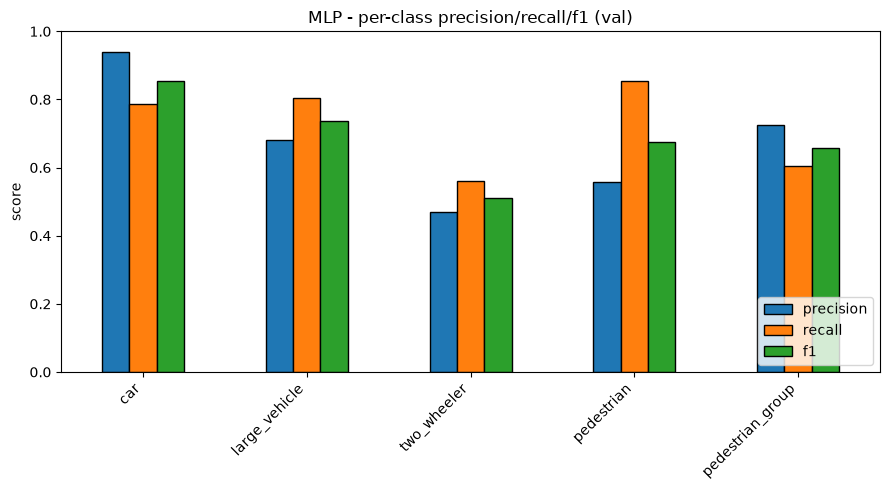

In [9]:
import json
from mlp_classifier import MLP_DIR

# cached, no retraining - per-class F1 by hidden_dim
hidden_per_class = {}
for variant in ["hidden8", "baseline", "hidden32", "hidden64"]:
    _, _, m, _, _ = run_variant(df, variant)
    hidden_per_class[variant] = m["f1"]
hidden_class_df = pd.DataFrame(hidden_per_class).T
hidden_spread = hidden_class_df.max() - hidden_class_df.min()

# cached val_metrics.json for each split-sensitivity fold - the noise reference
split_per_class = {}
for i in range(6):
    d = json.loads((MLP_DIR / "split_search" / f"fold_{i}" / "mlp_val_metrics.json").read_text())
    split_per_class[f"fold_{i}"] = {c: d[c]["f1"] for c in baseline_metrics.index}
split_class_df = pd.DataFrame(split_per_class).T
split_spread = split_class_df.max() - split_class_df.min()

pd.DataFrame({"hidden_dim spread (8-64)": hidden_spread, "split-choice spread (6 folds, noise reference)": split_spread})

No, not even per class. `pedestrian_group`'s hidden_dim spread (0.026) is the largest of any class, but that's still smaller than its own split-choice spread (0.117), and every other class shows the same pattern: whatever hidden_dim does to a class's F1 is dwarfed by what mere split choice already does to that same class. `two_wheeler` makes this starkest, spread of 0.005 from capacity against 0.386 from split choice alone. No class benefits from more or less capacity, the macro average wasn't hiding anything.

## Architecture depth: deep10 ablation (10 hidden layers)

Does going deeper help where going wider (previous section) didn't? Same features/taxonomy/N_BINS=16 as `baseline`, only depth varies: `n_hidden_layers=10` instead of 2, same `hidden_dim=16`. Defined in `scripts/mlp_variants.py`'s `deep10`.

First attempt (dropout=0.3, no batch normalization, lr=1e-5) collapsed to predicting only the majority class (`car`) for every point, macro F1 0.122 - a vanishing-gradient failure from stacking 10 unnormalized layers, not a real depth result. Not re-run here; full story in `MLP_Decisions_and_Findings.md` section 7. Fixed by adding batch normalization after each hidden layer, easing dropout to 0.1, and raising the learning rate to 1e-3.

/home/bruno/radar_machine_learning_ws/results/mlp/deep10/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/deep10/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/deep10/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.936   0.824  0.877    31055
large_vehicle         0.889   0.768  0.824     6247
two_wheeler           0.542   0.482  0.510     4629
pedestrian            0.541   0.940  0.687    11325
pedestrian_group      0.719   0.586  0.646    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/deep10/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/deep10/mlp_precision_recall_f1.png


,precision,recall,f1,support
car,0.935777,0.824376,0.876551,31055
large_vehicle,0.889445,0.767568,0.824025,6247
two_wheeler,0.542072,0.481529,0.510010,4629
pedestrian,0.540994,0.940397,0.686853,11325
pedestrian_group,0.718954,0.586460,0.645983,17858


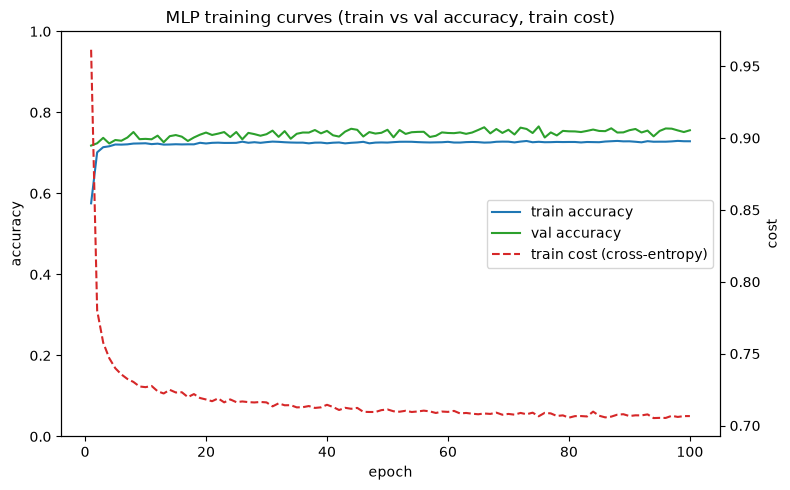

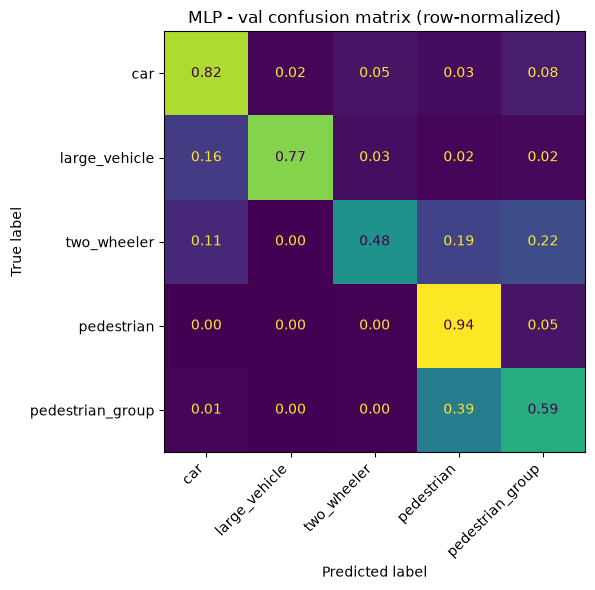

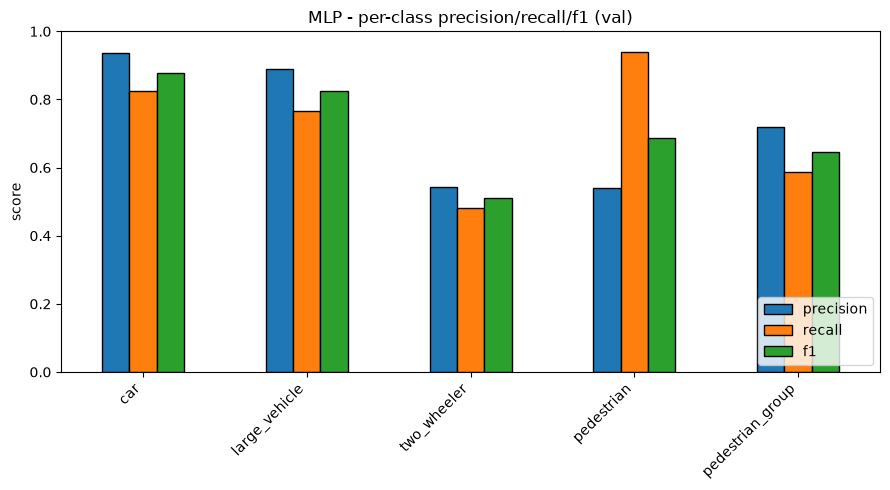

In [10]:
# cached, no retraining - the fixed (batch_norm + eased dropout + higher lr) config
_, _, deep10_metrics, _, _ = run_variant(df, "deep10")
deep10_metrics

In [11]:
# per-class delta vs baseline, checked against the same split-choice noise reference used for the hidden_dim sweep
delta = deep10_metrics["f1"] - baseline_metrics["f1"]
pd.DataFrame({
    "baseline_f1": baseline_metrics["f1"],
    "deep10_f1": deep10_metrics["f1"],
    "delta": delta,
    "split-choice spread (noise reference)": split_spread,
})

,baseline_f1,deep10_f1,delta,split-choice spread (noise reference)
car,0.853802,0.876551,0.022750,0.055956
large_vehicle,0.756059,0.824025,0.067966,0.196742
two_wheeler,0.507601,0.510010,0.002409,0.385549
pedestrian,0.681956,0.686853,0.004897,0.073356
pedestrian_group,0.632295,0.645983,0.013688,0.116629


Macro F1: 0.709 (`deep10`) vs 0.686 (`baseline`), delta +0.023. Looks like a gain, but every per-class delta sits inside that class's own split-choice noise spread (same reference as the capacity check above), including the two largest-looking deltas, `car` (+0.023 vs spread 0.056) and `large_vehicle` (+0.068 vs spread 0.197). `two_wheeler`, the class actually driving the macro F1 ceiling, barely moves (+0.002 vs spread 0.386).

**Finding:** not a real improvement. Depth doesn't help once it's actually trainable, same conclusion as the width sweep: the histogram feature representation is the ceiling, not model capacity in either dimension.

**Decision:** retain the 2-hidden-layer baseline.

Also surfaced a real caching bug along the way: `evaluate_val_metrics` reused a stale `mlp_val_metrics.json` from the collapsed first attempt after `deep10` was retrained in place with the fixed config, since it only checked that the file existed, not whether it still matched the current model. Fixed by invalidating the cache whenever it's older than the model file. Full writeup: `MLP_Decisions_and_Findings.md` section 7.

## Feature design: point count

Histogram features are fraction-of-points-per-bin, discarding instance point count entirely. Two ways to put it back: `n_points` (baseline plus one extra scalar, raw point count appended unbinned) and `raw_counts` (baseline with unnormalized per-bin counts instead of fractions, `normalize=false`). Defined in `scripts/mlp_variants.py`.

/home/bruno/radar_machine_learning_ws/results/mlp/n_points/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/n_points/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/n_points/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.938   0.788  0.856    31055
large_vehicle         0.745   0.797  0.770     6247
two_wheeler           0.480   0.553  0.514     4629
pedestrian            0.553   0.861  0.674    11325
pedestrian_group      0.698   0.602  0.646    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/n_points/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/n_points/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/raw_counts/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/raw_counts/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/raw_counts/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.936   0.786  0.855    31055
large_vehicle         0.721   0.796  0.757     6247
two_wheeler           0.489   0.544  0.515     4629
pedestrian            0.546   0.908  0.682    11325
pedestrian_group      0.728   0.576  0.643    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/raw_counts/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/raw_counts/mlp_precision_recall_f1.png


,baseline,n_points,raw_counts
car,0.853802,0.856123,0.854698
large_vehicle,0.756059,0.770195,0.756675
two_wheeler,0.507601,0.514062,0.514730
pedestrian,0.681956,0.673875,0.681776
pedestrian_group,0.632295,0.646364,0.642908


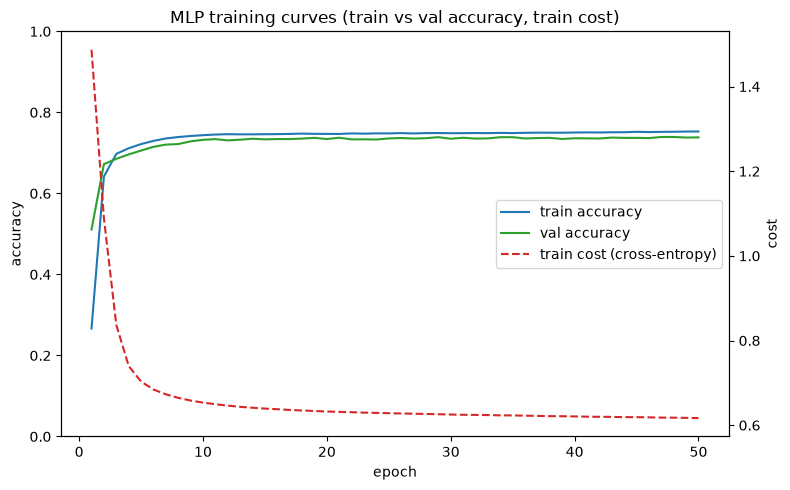

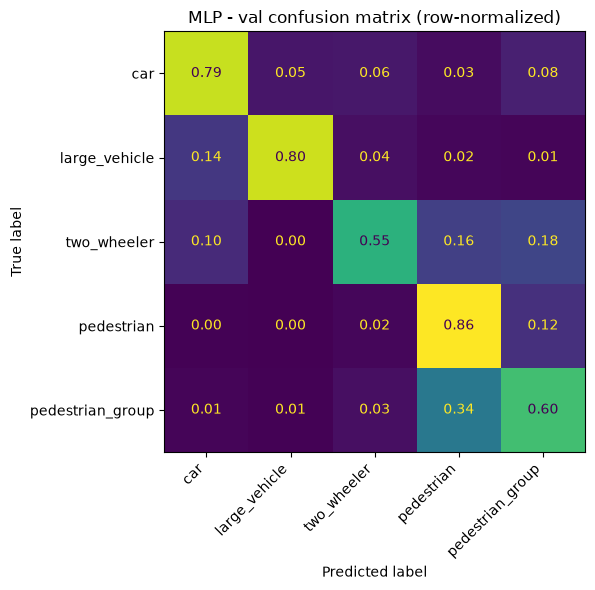

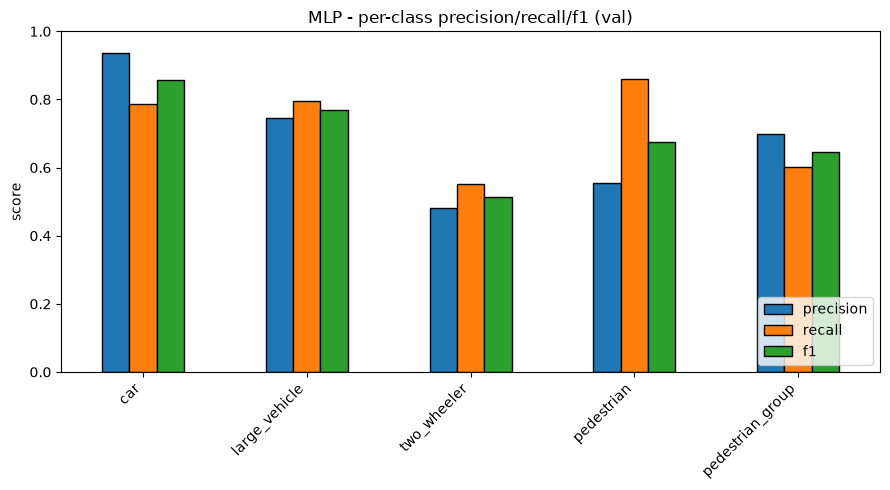

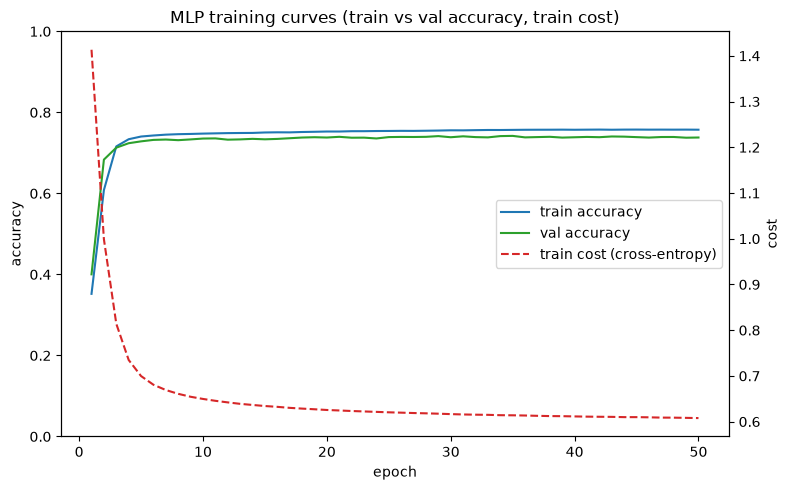

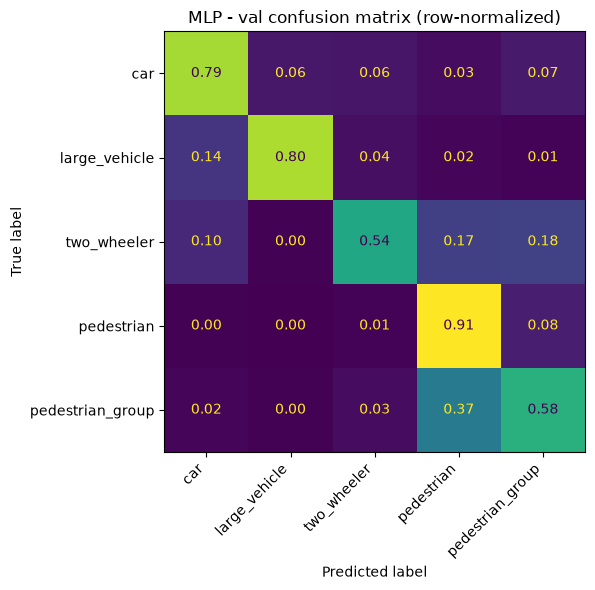

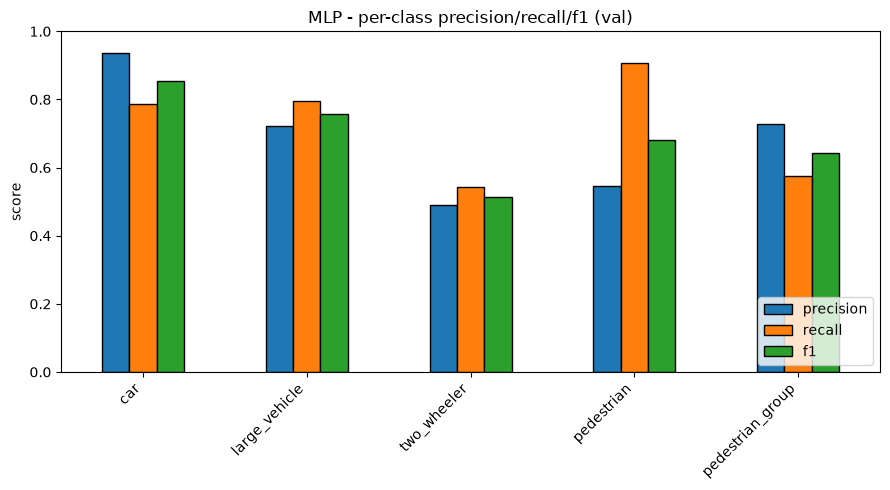

In [12]:
# both cached, no retraining
_, _, n_points_metrics, _, _ = run_variant(df, "n_points")
_, _, raw_counts_metrics, _, _ = run_variant(df, "raw_counts")
pd.DataFrame({
    "baseline": baseline_metrics["f1"],
    "n_points": n_points_metrics["f1"],
    "raw_counts": raw_counts_metrics["f1"],
})

Macro F1: `baseline` 0.686, `n_points` 0.692, `raw_counts` 0.690, both inside the noise floor per-class too. Both nudge the `pedestrian`/`pedestrian_group` precision/recall balance the theoretically expected way, but neither shift clears noise.

**Finding:** not a real improvement, by either route, two independent mechanisms for handing the network point count converge on the same null result. Full writeup: `MLP_Decisions_and_Findings.md` section 8.

## Feature design: orientation and angular features

`x_rel`/`y_rel` are per-point and orientation-dependent (a car seen broadside vs head-on spreads very differently across the two axes for the same physical object). Two tests: `spatial_extent` drops them for one orientation-robust scalar per instance (bounding-box diagonal); `azimuth_extent` adds a new scalar on top of `baseline` instead (angular spread as seen by the sensor, max-min of `azimuth_sc`, a point-level column nothing had used until now). Defined in `scripts/mlp_variants.py`.

/home/bruno/radar_machine_learning_ws/results/mlp/spatial_extent/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/spatial_extent/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/spatial_extent/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.942   0.782  0.855    31055
large_vehicle         0.715   0.801  0.756     6247
two_wheeler           0.465   0.553  0.505     4629
pedestrian            0.545   0.928  0.687    11325
pedestrian_group      0.751   0.570  0.648    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/spatial_extent/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/spatial_extent/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/azimuth_extent/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/azimuth_extent/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/azimuth_extent/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.941   0.790  0.859    31055
large_vehicle         0.723   0.799  0.759     6247
two_wheeler           0.496   0.571  0.531     4629
pedestrian            0.542   0.932  0.685    11325
pedestrian_group      0.756   0.565  0.647    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/azimuth_extent/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/azimuth_extent/mlp_precision_recall_f1.png


,baseline,spatial_extent,azimuth_extent
car,0.853802,0.854865,0.859018
large_vehicle,0.756059,0.755643,0.758935
two_wheeler,0.507601,0.505031,0.531124
pedestrian,0.681956,0.687188,0.685484
pedestrian_group,0.632295,0.647947,0.646814


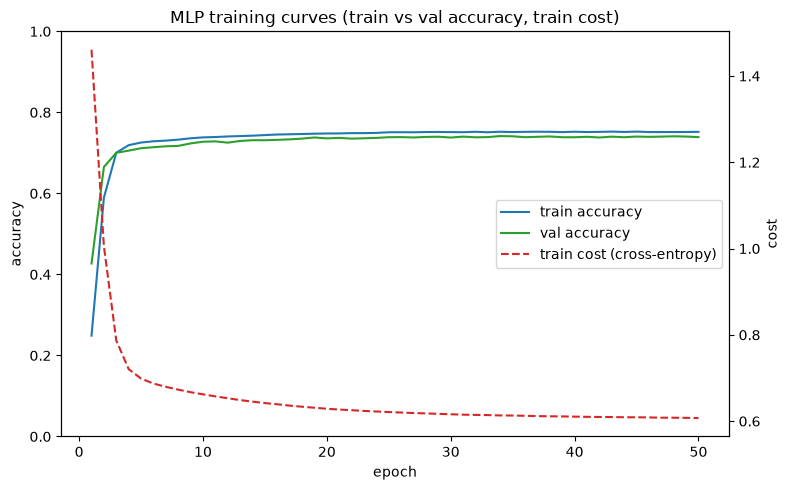

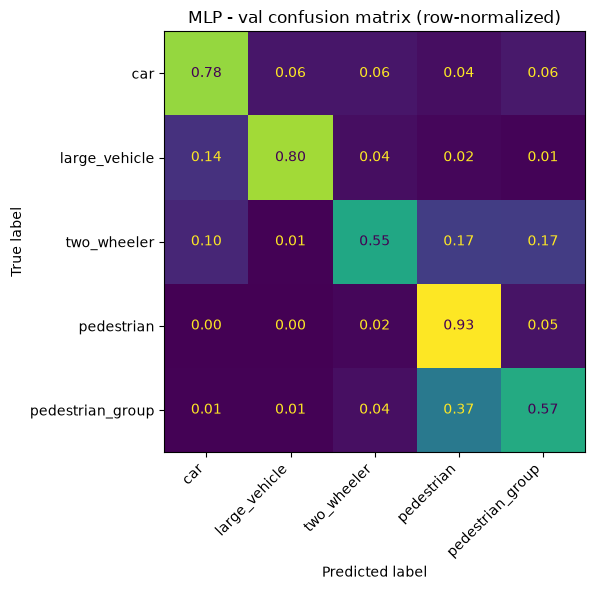

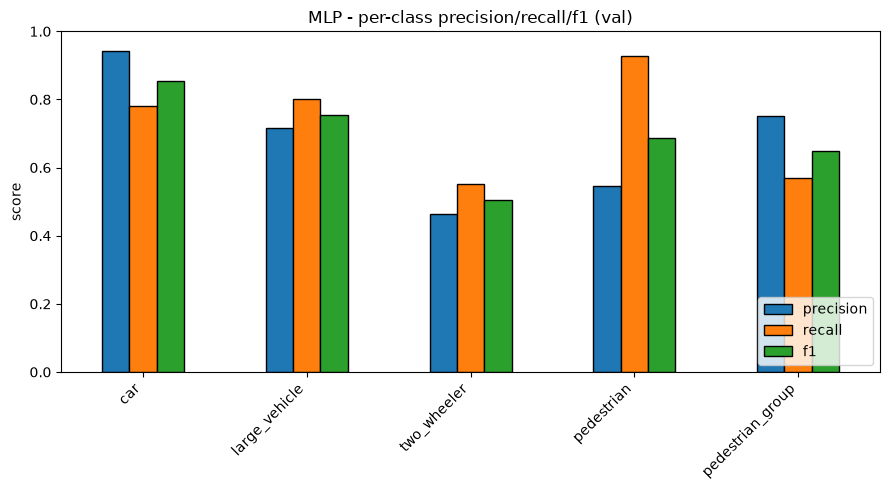

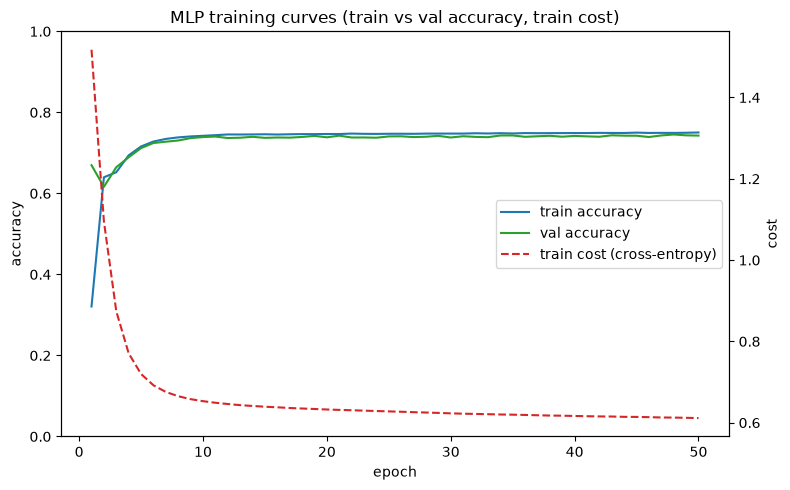

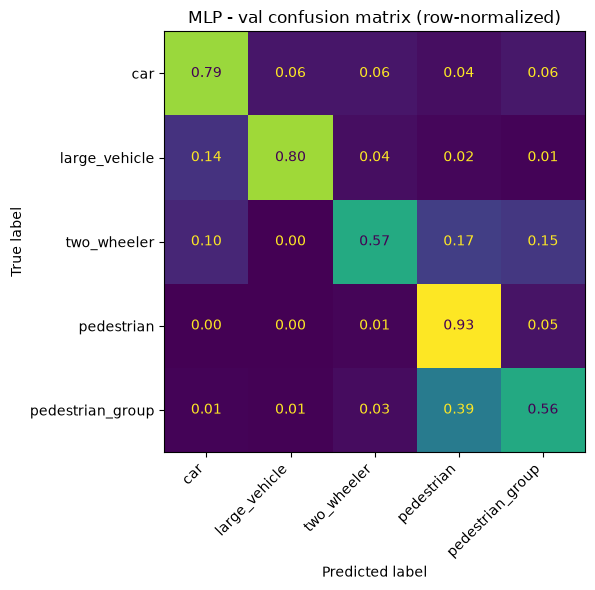

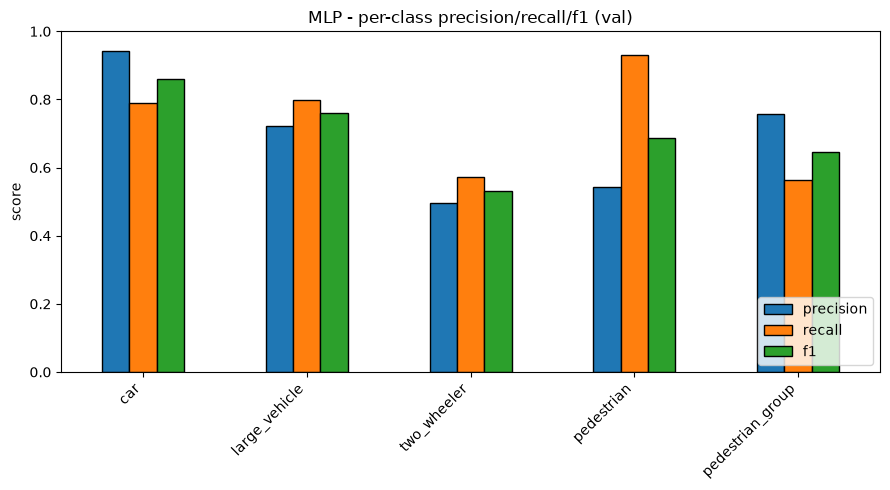

In [13]:
# both cached, no retraining
_, _, spatial_extent_metrics, _, _ = run_variant(df, "spatial_extent")
_, _, azimuth_extent_metrics, _, _ = run_variant(df, "azimuth_extent")
pd.DataFrame({
    "baseline": baseline_metrics["f1"],
    "spatial_extent": spatial_extent_metrics["f1"],
    "azimuth_extent": azimuth_extent_metrics["f1"],
})

Macro F1: `baseline` 0.686, `spatial_extent` 0.690, `azimuth_extent` 0.696. Every per-class delta sits inside the split-choice noise floor; `azimuth_extent`'s `two_wheeler` delta (+0.023) is the largest of any feature-design test so far, still a fraction of that class's 0.386 noise spread.

### Does spatial_extent narrow the noise floor itself?

`spatial_extent` was built to remove the orientation-sensitivity mechanism thought to drive part of the split-to-split noise (see Key takeaways in `MLP_Decisions_and_Findings.md`), so baseline's noise floor isn't automatically the right reference for it. Checked directly: reran the same 6-split sweep with `spatial_extent`'s feature set (`split_sensitivity.run_split_sensitivity`'s `features`/`extra_features`/`output_subdir` params), cached at `results/mlp/split_search_spatial_extent/fold_<n>/`, loaded here rather than rerun (~20min for 6 folds).

In [14]:
# loads cached fold results for both feature sets - no retraining
spatial_extent_split_per_class = {}
for i in range(6):
    d = json.loads((MLP_DIR / "split_search_spatial_extent" / f"fold_{i}" / "mlp_val_metrics.json").read_text())
    spatial_extent_split_per_class[f"fold_{i}"] = {c: d[c]["f1"] for c in baseline_metrics.index}
spatial_extent_split_class_df = pd.DataFrame(spatial_extent_split_per_class).T
spatial_extent_split_spread = spatial_extent_split_class_df.max() - spatial_extent_split_class_df.min()

pd.DataFrame({
    "baseline split-choice spread": split_spread,
    "spatial_extent split-choice spread": spatial_extent_split_spread,
})

,baseline split-choice spread,spatial_extent split-choice spread
car,0.055956,0.055087
large_vehicle,0.196742,0.167084
two_wheeler,0.385549,0.355660
pedestrian,0.073356,0.074278
pedestrian_group,0.116629,0.115436


Not meaningfully narrower. Macro F1 across the same 6 splits ranged 0.655-0.745 (std 0.030) vs baseline's 0.651-0.734 (std 0.027), essentially unchanged. `large_vehicle` and `two_wheeler`, the classes an orientation fix would most plausibly help, shrank a little (0.197->0.167, 0.386->0.356) but not enough to matter; `car`/`pedestrian`/`pedestrian_group` were flat.

**Finding:** sixth independent axis (capacity, depth, `n_points`, `raw_counts`, `spatial_extent`, `azimuth_extent`) landing inside the noise floor, both on the fixed baseline split and, for `spatial_extent`, across the noise floor itself. Reinforces that the ceiling isn't from any one specific feature-engineering choice, it's more fundamental to what this per-instance summary vector can express at ~2.9 points/instance average. Full writeup: `MLP_Decisions_and_Findings.md` section 9.

## Summary

| variant | macro F1 | notes |
|---|---|---|
| `bus_separate` (6 classes) | 0.611 | original taxonomy, superseded |
| `baseline` (5 classes, bus merged) | 0.686 | standing model |
| `truck_separate` (7 classes) | 0.541 | confirms truck merge was correct |
| `range_sc` | 0.704 | looked better, confirmed noise (see split sensitivity) |
| `bs32` | 0.687 | no real difference from baseline |
| `hidden8`/`hidden32`/`hidden64` | 0.688 / 0.688 / 0.688 | no capacity effect, feature ceiling not model ceiling |
| `deep10` (10 hidden layers) | 0.709 | looked better, confirmed noise (per-class deltas inside split-choice spread) |
| `n_points` / `raw_counts` | 0.692 / 0.690 | point count, explicit or implicit, both inside noise |
| `spatial_extent` / `azimuth_extent` | 0.690 / 0.696 | orientation-robust / angular features, both inside noise |
| split sensitivity, 6 valid splits | 0.651 - 0.734 | noise floor for any single-split comparison here |
| split sensitivity, spatial_extent features | 0.655 - 0.745 | same noise floor check, different feature set - essentially unchanged |

Standing model: `baseline`, 5 classes, `BATCH_SIZE=128`, `EPOCHS=50`, `HIDDEN_DIM=16`, 2 hidden layers, `doppler_spread` feature set. Anything smaller than roughly a 3 point macro F1 gap shouldn't be trusted from a single split.

Full writeup, reasoning, and the general lesson on split sensitivity: `MLP_Decisions_and_Findings.md`.